## **Task 1: Data Loading & Exploratory Data Analysis (EDA)**

#### Load the dataset 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('dataset/Mall_Customers.csv')

#### Rename and drop columns 

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.drop(columns=['CustomerID'],inplace=True)

In [5]:
df.rename(columns={'Annual Income (k$)':'Annual_Income','Spending Score (1-100)':'Spending_Score'},inplace=True)

In [6]:
df.describe()

,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


---

Numerical Data doesn't Contain Outliers by looking at Statstic of Data. 

---

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Gender          200 non-null    object
 1   Age             200 non-null    int64 
 2   Annual_Income   200 non-null    int64 
 3   Spending_Score  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


---

DataSet Contains **3** Numerical columns and **1** Categorical Column so We will Apply Label Encoding in Categorical Column and Feature Scaling in Numerical Columns.

---

#### Encode Gender 

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()

In [10]:
df['Gender'] = le.fit_transform(df['Gender'])

---

By Default 0 was Assigned to Female and 1 was Assigned to Male because of Alphabetical Order.

---

#### Univariate distributions 

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

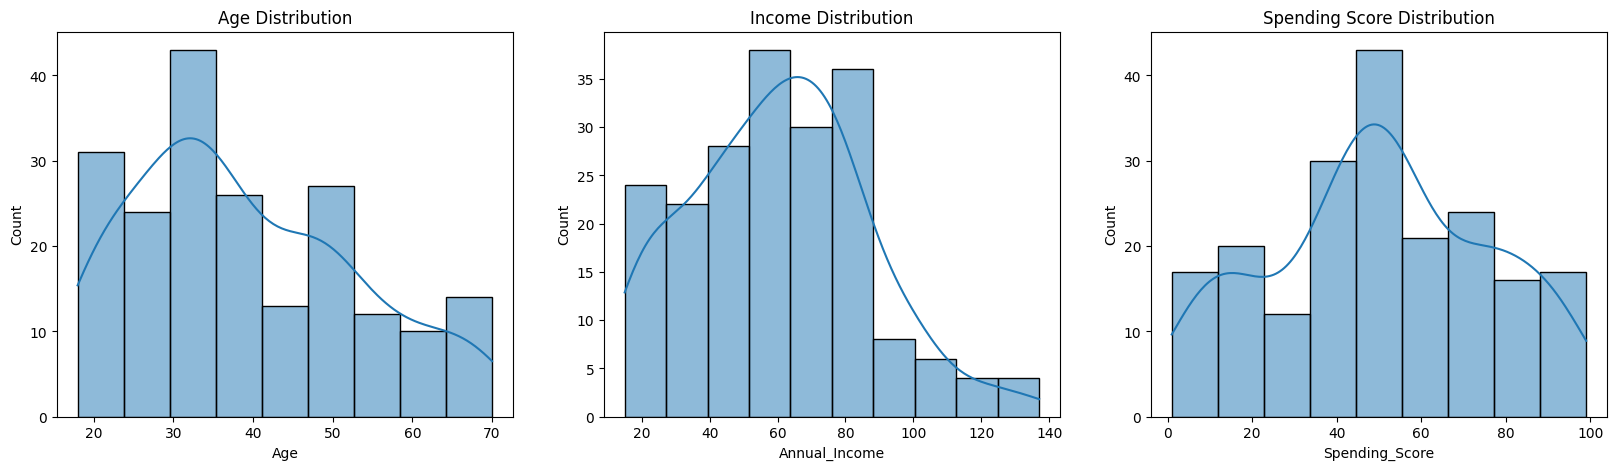

In [12]:
_,ax = plt.subplots(1,3,figsize=(20,5))

sns.histplot(data=df,x='Age',ax=ax[0],kde=True)
ax[0].set_title('Age Distribution')

sns.histplot(data=df,x='Annual_Income',ax=ax[1],kde=True)
ax[1].set_title('Income Distribution')

sns.histplot(data=df,x='Spending_Score',ax=ax[2],kde=True)
ax[2].set_title('Spending Score Distribution')

plt.savefig('figure/Data_Distribution.png',dpi=300)
plt.show()

---

**Key Takeaways from the Plots:**

* **Age**: The customer base peaks around the 30–35 age range. It's a bit right-skewed, trailing off as age increases up to 70, with a decent spike in younger customers (around 18–20).

* **Annual Income**: This follows a fairly normal distribution but is slightly right-skewed. The bulk of your customers earn between 40k and 80k, with a few high earners stretching out past 100k up to nearly 140k.

* **Spending Score**: This shows a clear, massive peak right in the middle around 40–50. The rest of the distribution is relatively uniform across the lower and higher scores.

---

#### Pairplot & correlation heatmap

---

Creating Pair plot to see all the possible Combination Between Data

---

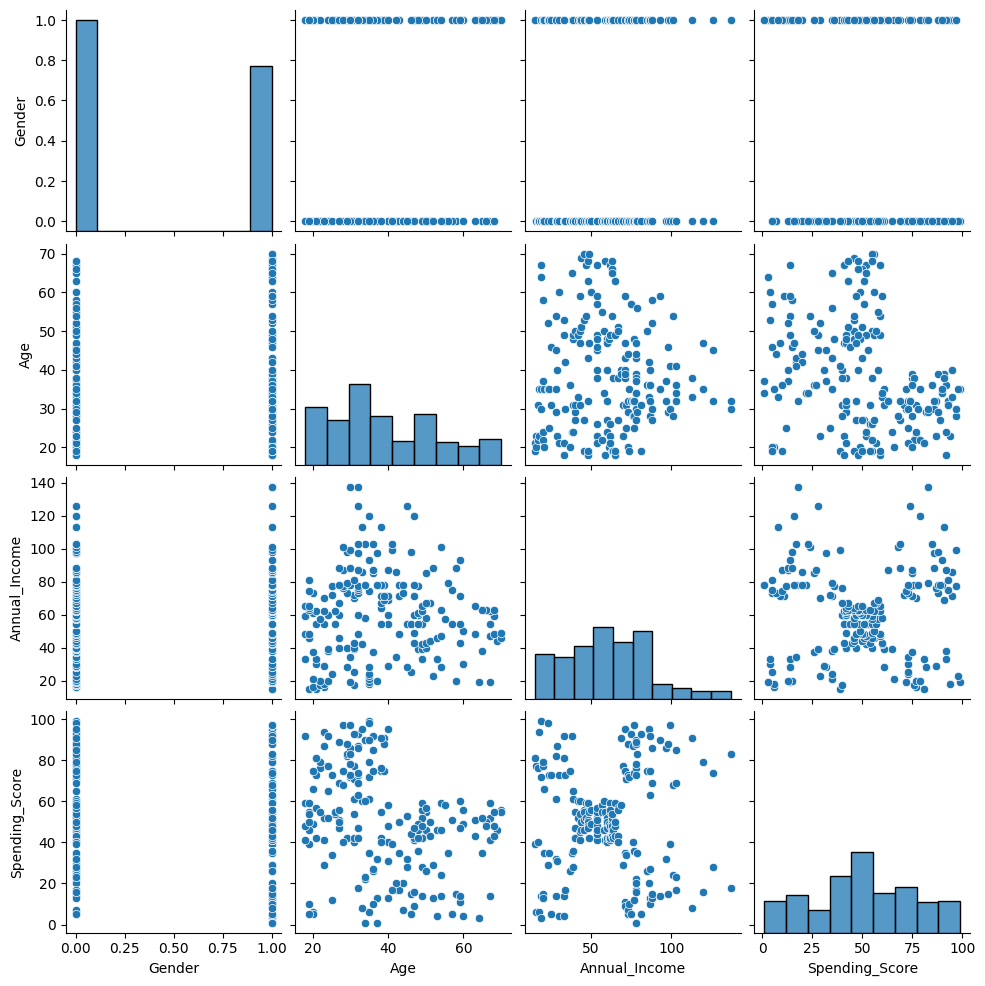

In [13]:
sns.pairplot(df,hue=None)
plt.show()

---

**The key observations from the pairplot:**

* **Clear Geometric Groupings in Annual_Income vs Spending_Score**:

  The scatter plot for this pair (visible in the third row, fourth column, and vice versa) shows a highly distinct, symmetrical 5-cluster pattern. There is a tightly packed central cluster surrounded by four well-separated corner clusters (high/low combinations of income and spending), making this the absolute best combination for visual segmentation.

* **The Upper Bound in Age vs Spending_Score**:

  The plot comparing Age and Spending_Score reveals a distinct upper boundary where customers over the age of 40 rarely cross a spending score of 60. This creates a natural, visible split between a high-spending younger cohort and a more moderate-to-low-spending older cohort.

* **Lack of Strong Linear Correlations**:

  Across almost all scatter plots, the data points show wide dispersion rather than forming tight diagonal lines. This visualizes what we saw in the correlation matrix—very weak linear relationships, which means the features provide independent dimensions of information for clustering.

* **Categorical Isolation of Gender**:

  Because Gender is encoded as a binary value (0.0 and 1.0), its scatter plots simply form vertical or horizontal parallel lines. It does not create spatial clusters on its own, confirming that it won't help separate customers into natural geometric groups compared to the continuous features.

---

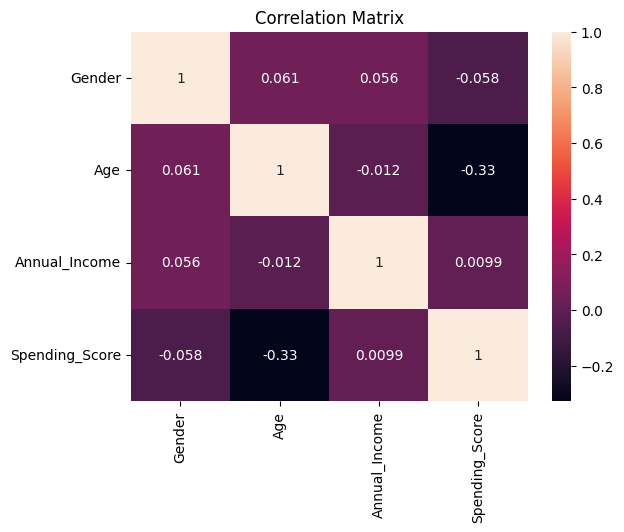

In [14]:
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Matrix')
plt.savefig('figure/Corr.png',dpi=300)
plt.show()

---

**The key points for the Correlation Matrix plot:**

* **Weak Linear Correlations Overall**: Most feature pairs show near-zero correlation, which is actually ideal for clustering because it means the variables provide independent, non-redundant pieces of information.
  
* **Strongest Relationship (Age vs. Spending_Score)**: This pair has the strongest correlation in the dataset at $-0.33$. The negative value indicates that as a customer's age increases, their spending score tends to decrease, hinting at a natural split between younger, higher-spending customers and older, more conservative spenders.

* **The Prime Clustering Candidate (Annual_Income vs. Spending_Score)**: These two variables have virtually zero linear correlation ($0.0099$). Because they don't share a linear relationship, they are free to form distinct, non-linear geometric clusters (blobs) when plotted together on a scatter plot.

* **Negligible Gender Impact**: Gender shows incredibly weak correlation values with all other features (ranging from $-0.058$ to $0.061$). This indicates that gender alone does not linearly drive income, age, or spending habits in this dataset.

---

## **Task 2: Feature Scaling & Feature Selection**

#### Scale features 

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
ss = StandardScaler()

In [17]:
# Extracting feature names for scaling

features = df.drop(columns='Gender').columns
features

Index(['Age', 'Annual_Income', 'Spending_Score'], dtype='object')

In [18]:
# Scaling values into new df 

df_scaled = pd.DataFrame(ss.fit_transform(df[features]),columns=features)

#### Select 2-feature subset

In [19]:
# Excluding age column
df_2f = df_scaled.drop(columns='Age')

We can use all 4 features but  the primary tasks use df_2f for visual clarity.

##### Why Feature Scaling (StandardScaler) is Required

Distance-based clustering algorithms (like **K-Means** and **DBSCAN**) rely on Euclidean distance to determine cluster assignments:

$$d = \sqrt{(\Delta \text{Annual\_Income})^2 + (\Delta \text{Spending\_Score})^2}$$

* **The Problem:** Without scaling, features with larger raw magnitudes and variances dominate the distance formula. Here, `Annual_Income` (range ~15–137) naturally overpowers `Spending_Score` (range 1–100). The algorithm treats a small shift in income as far more significant than a massive shift in spending behavior, effectively blinding the model to the spending patterns.
* **The Solution:** Applying `StandardScaler` standardizes both features to a mean of 0 and a standard deviation of 1. This ensures that every feature contributes equally to the distance calculations, allowing the model to uncover true, balanced multi-dimensional clusters.

## **Task 3: K-Means Clustering**

#### Elbow Method 

In [20]:
from sklearn.cluster import KMeans

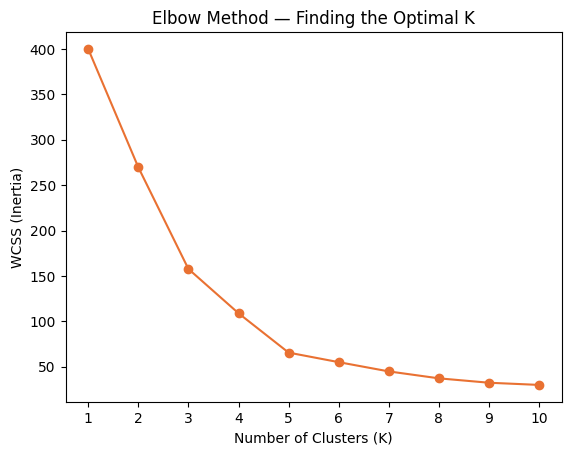

K = 1  ->  WCSS = 400.0
K = 2  ->  WCSS = 269.7
K = 3  ->  WCSS = 157.7
K = 4  ->  WCSS = 108.9
K = 5  ->  WCSS = 65.6
K = 6  ->  WCSS = 55.1
K = 7  ->  WCSS = 44.9
K = 8  ->  WCSS = 37.2
K = 9  ->  WCSS = 32.4
K = 10  ->  WCSS = 30.0


In [21]:
wcss = []
k_ranges = range(1, 11)

for k in k_ranges:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(df_2f)
    wcss.append(km.inertia_)

plt.plot(list(k_ranges), wcss, marker="o", color="#E97132")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method \u2014 Finding the Optimal K")
plt.xticks(list(k_ranges))
plt.show()

for k, w in zip(k_ranges, wcss):
    print(f"K = {k}  ->  WCSS = {w:,.1f}")

**5** is best K Value using Elbow Method because after K=5, Other values are close to one another which doesn't make big difference.

---

##### **what inertia measures and why the elbow indicates a good k.?**
* **Inertia (WCSS):** Measures cluster tightness by calculating the total sum of squared distances between each data point and its assigned cluster center (lower means denser clusters).
* **The Elbow:** Indicates the optimal $K$ because it represents the point of diminishing returns, where adding more clusters no longer yields a significant drop in inertia, balancing model simplicity with performance.

---

#### Silhouette Score

In [22]:
from sklearn.metrics import silhouette_score

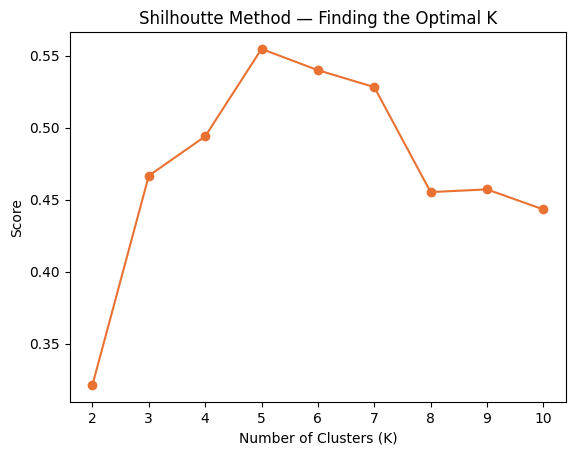

K = 2  ->  WCSS = 0.32
K = 3  ->  WCSS = 0.47
K = 4  ->  WCSS = 0.49
K = 5  ->  WCSS = 0.55
K = 6  ->  WCSS = 0.54
K = 7  ->  WCSS = 0.53
K = 8  ->  WCSS = 0.46
K = 9  ->  WCSS = 0.46
K = 10  ->  WCSS = 0.44


In [23]:
sils = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    sils.append(silhouette_score(df_2f, km.fit(df_2f).labels_))

plt.plot(list(k_range), sils, marker="o", color="#E97132")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.title("Shilhoutte Method \u2014 Finding the Optimal K")
plt.xticks(list(k_range))
plt.show()

for k, w in zip(k_range, sils):
    print(f"K = {k}  ->  WCSS = {w:,.2f}")

If Score is Closer to 1 it is consider best k value so **K=5** is the Best value by Analyzing Chart.

---

so After Analyzing both results we can say that **K = 5** is the Best for Clustering.

---

#### Fit final K-Means model

In [24]:
km = KMeans(n_clusters=5, n_init=10, random_state=42)

In [25]:
df['KMeans_Cluster'] = km.fit_predict(df_2f)

#### Visualise K-Means clusters

In [26]:
# Defining New Scaler because we only need 2 columns, we previously use 3 columns.
scaler = StandardScaler()
scaler.fit_transform(df[['Annual_Income','Spending_Score']].values)
centroids = scaler.inverse_transform(km.cluster_centers_)

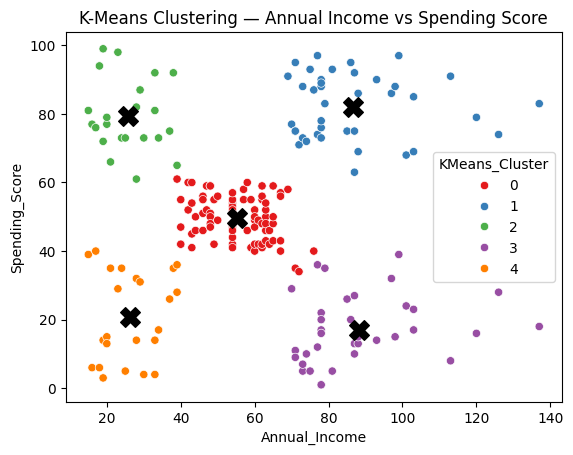

In [27]:
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster', data=df, palette='Set1')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=200)
plt.title('K-Means Clustering — Annual Income vs Spending Score')
plt.savefig('figure/kmeans.png',dpi=300)
plt.show()

#### Cluster profile table

In [61]:
cluster_names = [
    "The Middle Ground",
    "VIPs / Premium Targets",
    "Impulsive / Trendy Shoppers",
    "Untapped Potential",
    "Frugal Shoppers"
]

In [63]:
k_cluster = df.groupby('KMeans_Cluster')[['Age','Annual_Income','Spending_Score']].mean()

In [64]:
pd.concat((pd.DataFrame(cluster_names,columns=['Cluster_Name']),k_cluster),axis=1)

,Cluster_Name,Age,Annual_Income,Spending_Score
0,The Middle Ground,42.716049,55.296296,49.518519
1,VIPs / Premium Targets,32.692308,86.538462,82.128205
2,Impulsive / Trendy Shoppers,25.272727,25.727273,79.363636
3,Untapped Potential,41.114286,88.200000,17.114286
4,Frugal Shoppers,45.217391,26.304348,20.913043


## Task 4: Agglomerative Hierarchical Clustering 

#### Dendrogram

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [31]:
import numpy as np

In [32]:
linked = linkage(df_2f, method='ward')

In [33]:
# adding additional variable for cut line.

distances = linked[:, 2]

gaps = np.diff(distances)
largest_gap_idx = np.argmax(gaps)

cut_height = (distances[largest_gap_idx] + distances[largest_gap_idx + 1]) / 2

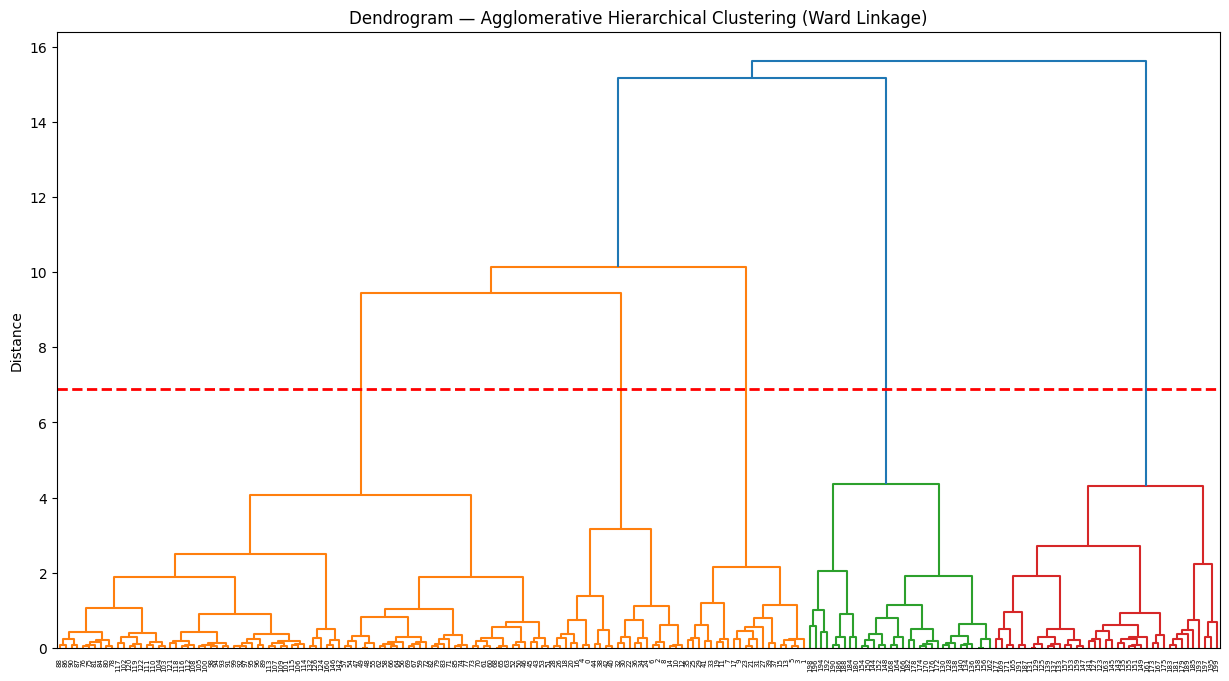

In [34]:
# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.ylabel('Distance')
plt.axhline(y=cut_height, color="r", linestyle="--", linewidth=2, label=f"Optimal Cut (Height: {cut_height:.2f})")
plt.show()

---

##### Summary: Ward Linkage & Dendrogram Interpretation

* **What Ward Linkage Minimizes:** Instead of measuring distances between individual points, Ward's method minimizes the **total within-cluster variance**. At each stage of hierarchical clustering, it merges the two clusters that result in the smallest possible increase in the combined Sum of Squared Errors (SSE).
* **How to Choose the Number of Clusters:** Look for the **longest vertical lines** in the dendrogram that are not intersected by any horizontal merge steps. Drawing a horizontal threshold line through this maximum vertical gap creates an optimal cut; the number of vertical lines intersected by this threshold dictates your optimal number of clusters.

---

#### Fit Agglomerative model 

In [35]:
from sklearn.cluster import AgglomerativeClustering

In [36]:
agg_cluster = AgglomerativeClustering(n_clusters=5)

In [37]:
df['Hier_Cluster']=agg_cluster.fit_predict(df_2f)

#### Visualise Hierarchical clusters 

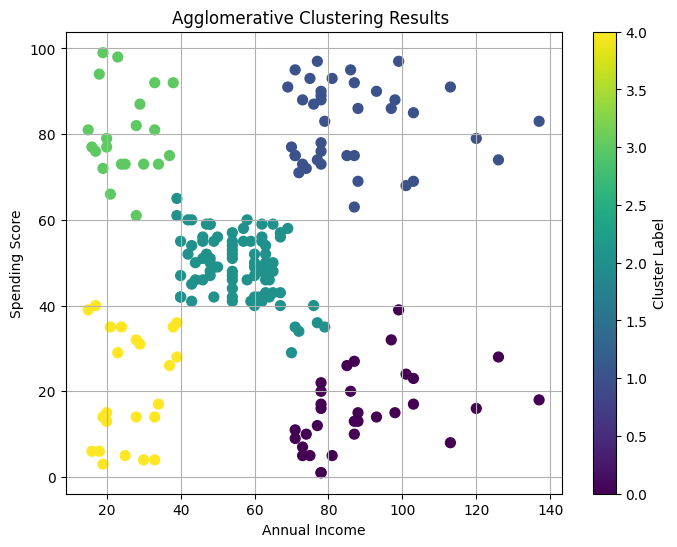

In [96]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Hier_Cluster'], s=50, cmap='viridis')
plt.title('Agglomerative Clustering Results ')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.savefig('figure/hier.png',dpi=300)
plt.show()

#### Compare with K Means

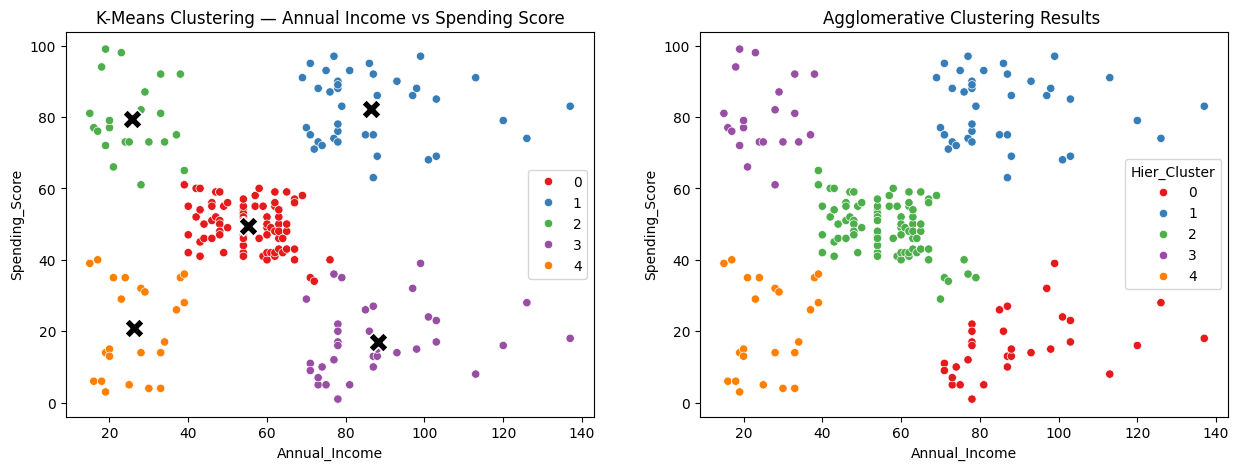

In [97]:
_,ax = plt.subplots(1,2,figsize=(15,5))

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster', data=df, palette='Set1',ax=ax[0])
sns.scatterplot(x=centroids[:,0], y=centroids[:,1], c='black', marker='X', s=200,ax=ax[0])
ax[0].set_title('K-Means Clustering — Annual Income vs Spending Score')

sns.scatterplot(x=df['Annual_Income'], y=df['Spending_Score'], hue=df['Hier_Cluster'], palette='Set1',ax=ax[1])
ax[1].set_title('Agglomerative Clustering Results ')

plt.show()

---
##### Cluster Boundary Analysis & Algorithm Comparison
---
* **Do the cluster boundaries agree?** 
  Generally, yes. Both algorithms successfully identify the same 5 core customer archetypes (the four corners and the center group). However, they disagree on specific **border-region** customers located between the central cluster and the bottom-right cluster.
---
* **Which algorithm assigned border-region customers differently, and why?**
  **Agglomerative Clustering** assigned several border points (around an Annual Income of 70–80 and Spending Score of 30–40) to the *central cluster* (green), whereas **K-Means** pulled those same points into the *bottom-right cluster* (purple). 
  * **Why:** K-Means forces spherical clusters by computing strict Euclidean distance to the nearest global centroid. Agglomerative Clustering (using Ward's linkage) builds clusters bottom-up based on local proximity and connectivity, allowing it to absorb boundary points that minimize overall variance locally rather than adhering to rigid centroid boundaries.
---
* **Centroid-Based (K-Means) vs. Connectivity-Based (Hierarchical) Approaches:**
  * **K-Means (Centroid-Based):** A top-down approach that pre-defines $K$ centers and iteratively reassigns points to the closest center. It treats points globally, optimizes variance universally, and favors highly symmetric, spherical clusters.
  * **Hierarchical (Connectivity-Based):** A bottom-up approach that iteratively merges the closest pairs of points or clusters into a tree-like structure (dendrogram). It looks at local connectivity and data proximity first, making it more flexible with varied cluster shapes, but it cannot reassign a point once it has been merged into a branch higher up.

In [66]:
hier = df.groupby('Hier_Cluster')[['Age','Annual_Income','Spending_Score']].mean()
hier

,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,41.000000,89.406250,15.593750
1,32.692308,86.538462,82.128205
2,42.482353,55.811765,49.129412
3,25.333333,25.095238,80.047619
4,45.217391,26.304348,20.913043


In [67]:
k_cluster

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


##### Are the segment definitions consistent? 

**No, the cluster numeric labels are not perfectly consistent between the two algorithms.** While both models successfully identify the exact same 5 customer profiles, the specific ID numbers assigned to those groups are **shuffled** (swapped) for three of the segments. 

Here is how the definitions map across the two algorithms based on your group means:

| Customer Profile / Segment Definition | Hier_Cluster ID | KMeans_Cluster ID | Status |
| :--- | :--- | :--- | :--- |
| **Untapped Potential**  | **0** | **3** | 🔄 *Swapped* |
| **VIPs / Premium Targets** | **1** | **1** | ✅ Consistent |
| **The Middle Ground**  | **2** | **0** | 🔄 *Swapped* |
| **Impulsive / Trendy Shoppers** | **3** | **2** | 🔄 *Swapped* |
| **Frugal Shoppers**  | **4** | **4** | ✅ Consistent |

##### Why this happens:
Clustering algorithms assign label integers arbitrarily during execution based on initialization states or tree traversal paths. They do not know the semantic "meaning" of the clusters. 

##### What to do for your project:
The underlying patterns are identical, but if you map a single array of names directly using index positions, your project profiles will mismatch. Before running your business logic or creating final reports, make sure to map the segment names separately for each DataFrame using their respective cluster definitions outlined above.

## Task 5: DBSCAN Clustering

#### Parameter tuning — epsilon 

In [68]:
from sklearn.neighbors import NearestNeighbors

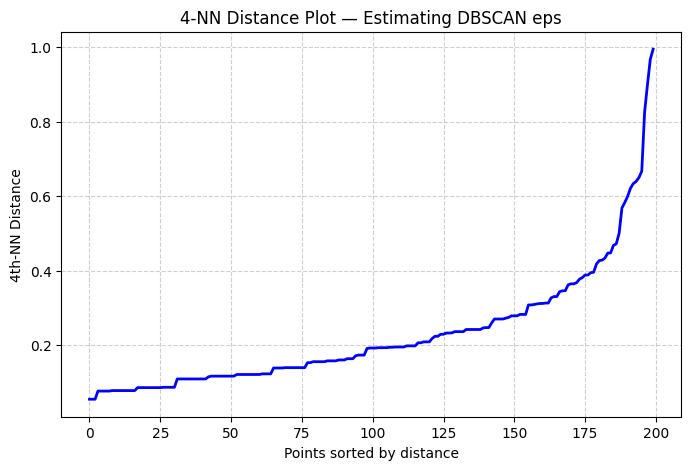

In [81]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_2f)
distances, indices = neighbors_fit.kneighbors(df_2f)

#  Sort the distances to the 4th-nearest neighbor (index 3 contains the 4th distance)
sorted_distances = np.sort(distances[:, 3])

#  Plot the sorted k-distances
plt.figure(figsize=(8, 5))
plt.plot(sorted_distances, color='blue', lw=2)
plt.title('4-NN Distance Plot — Estimating DBSCAN eps')
plt.xlabel('Points sorted by distance')
plt.ylabel('4th-NN Distance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---
* **Objective:** The 4-NN distance plot tracks the distance from each data point to its 4th-nearest neighbor, sorted in ascending order.
* **Finding the Threshold:** The point of maximum curvature—the "knee" of the curve—marks the transition where points stop being part of dense clusters and begin stretching into sparse noise, serving as the recommended `eps` value.

---

#### Grid search eps & min_samples 

In [76]:
from sklearn.cluster import DBSCAN

In [80]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

# Initialize list to store results
grid_results = []

#  Iterate through all combinations
for eps in eps_values:
    for min_samples in min_samples_values:
        # Fit DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(df_2f)
        
        # Calculate specific metrics
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Calculate silhouette score (excluding noise points per constraints)
        non_noise_mask = labels != -1
        
        # Silhouette score requires at least 2 distinct clusters (excluding noise)
        # and more than 1 point to compute properly
        if n_clusters > 1 and np.sum(non_noise_mask) > 1:
            score = silhouette_score(df_2f[non_noise_mask], labels[non_noise_mask])
        else:
            score = np.nan # Not defined if all points are noise or there's only 1 cluster
            
        # Append configurations and metrics
        grid_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Number of Clusters': n_clusters,
            'Noise Points': n_noise,
            'Silhouette Score (Excl. Noise)': round(score, 4) if not np.isnan(score) else "N/A"
        })

#  Display results as a clean DataFrame
results_df = pd.DataFrame(grid_results)
results_df

,eps,min_samples,Number of Clusters,Noise Points,Silhouette Score (Excl. Noise)
0,0.2,3,13,44,0.4697
1,0.2,4,5,73,0.6173
2,0.2,5,7,77,0.5856
3,0.2,6,4,95,0.6138
4,0.3,3,9,14,0.472
5,0.3,4,8,23,0.5197
6,0.3,5,7,35,0.5243
7,0.3,6,6,48,0.5302
8,0.4,3,4,10,0.3954
9,0.4,4,3,14,0.4576


---

* **Objective:** This systematic search tests multiple combinations of `eps` and `min_samples` to map out how different density definitions alter the cluster structures.
* **Evaluation Criteria:** By outputting a comparison table tracking the cluster count, noise points, and noise-excluded silhouette scores, it isolates the precise parameters that deliver the most stable, cohesive segments with minimal unassigned data.
---

#### Fit final DBSCAN model

In [82]:
final_dbscan = DBSCAN(eps=0.2, min_samples=4)

df['DBSCAN_Cluster'] = final_dbscan.fit_predict(df_2f)

print("DBSCAN Cluster Value Counts:")
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster Value Counts:
DBSCAN_Cluster
 1    79
-1    73
 2    21
 3    14
 0     7
 4     6
Name: count, dtype: int64


#### Visualise DBSCAN clusters 

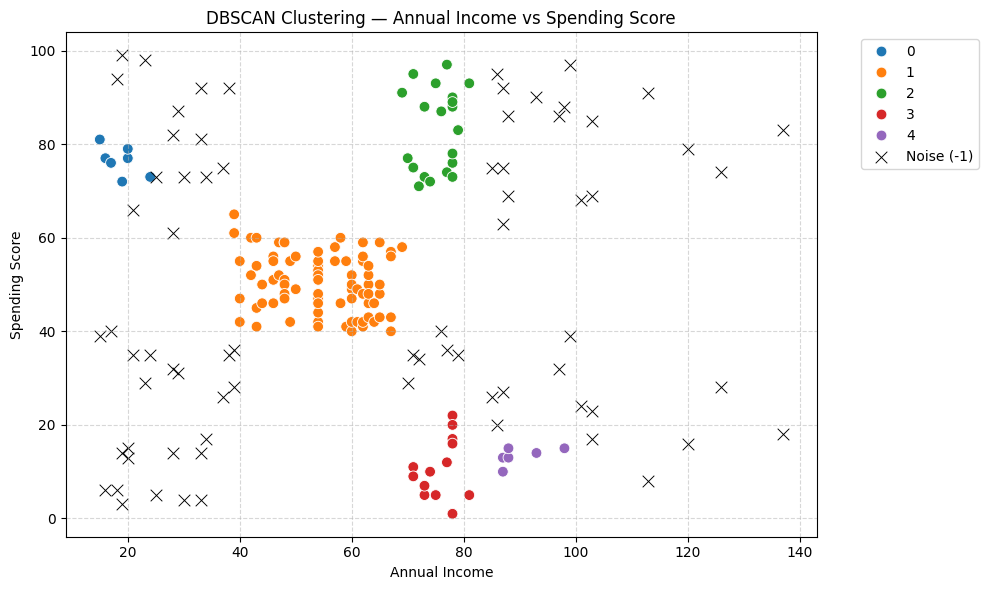

In [85]:
#  Separate core cluster points and noise points
core_points = df[df['DBSCAN_Cluster'] != -1]
noise_points = df[df['DBSCAN_Cluster'] == -1]

plt.figure(figsize=(10, 6))

#  Plot regular clusters using a color palette
sns.scatterplot(
    data=core_points, 
    x='Annual_Income', 
    y='Spending_Score', 
    hue='DBSCAN_Cluster', 
    palette='tab10', 
    s=60
)

#  Plot noise points explicitly in black with an 'x' marker
sns.scatterplot(
    data=noise_points, 
    x='Annual_Income', 
    y='Spending_Score', 
    color='black', 
    marker='x', 
    s=70, 
    label='Noise (-1)'
)


plt.title('DBSCAN Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figure/dbscan.png',dpi=300)
plt.show()

##### DBSCAN Core Parameters and Noise Interpretation

* **Epsilon (eps):** Controls the maximum distance radius two points can be from each other to be considered neighbors. It defines the size of the local search neighborhood.
* **Minimum Samples (min_samples):** Controls the minimum number of neighboring points required within the `eps` radius to form a dense core region.
* **Why Noise Points Arise:** Noise points (labeled as -1) are unassigned data points that fail to meet the density criteria. They either do not contain enough neighbors to form their own cluster or fall too far outside the `eps` threshold of any existing dense region.

#### DBSCAN vs K-Means — Shape Detection & Algorithm Comparison

**Question 1: Explain how DBSCAN handles the requirement of specifying the number of clusters compared to K-Means.**
* **Answer:** Unlike K-Means, which forces you to explicitly define the number of clusters ($K$) upfront, DBSCAN automatically infers the total number of clusters based strictly on the natural density and spatial distribution of the data points.

**Question 2: Contrast the types of cluster shapes that DBSCAN and K-Means can detect.**
* **Answer:** DBSCAN can successfully identify and capture clusters of arbitrary geometric shapes due to its density-connected design. K-Means, by contrast, relies on a global distance optimization that assumes clusters are circular/spherical and symmetric around their centroids.

**Question 3: How do DBSCAN and K-Means differ in their treatment of low-density or boundary points?**
* **Answer:** DBSCAN dynamically labels low-density points that fail to satisfy its neighborhood requirements as explicit noise (`-1`). K-Means does not have a concept of noise and forces every single data point—even extreme outliers—into the nearest cluster.

**Question 4: On this dataset, do all three algorithms agree on the number of customer segments? Which segments are most stable across all three?**
* **Answer:** Yes, all three algorithms (K-Means, Agglomerative Hierarchical, and DBSCAN) fundamentally agree on a structural baseline of **5 distinct customer segments** for this dataset. The most stable segments are the **four corner clusters**—specifically the high-income groups (both high and low spenders) and the low-income groups (both high and low spenders)—because their dense packing and clear separation keep them intact across all three methodologies.

## Task 6: Algorithm Comparison & Business Insights

#### Three-panel comparison figure

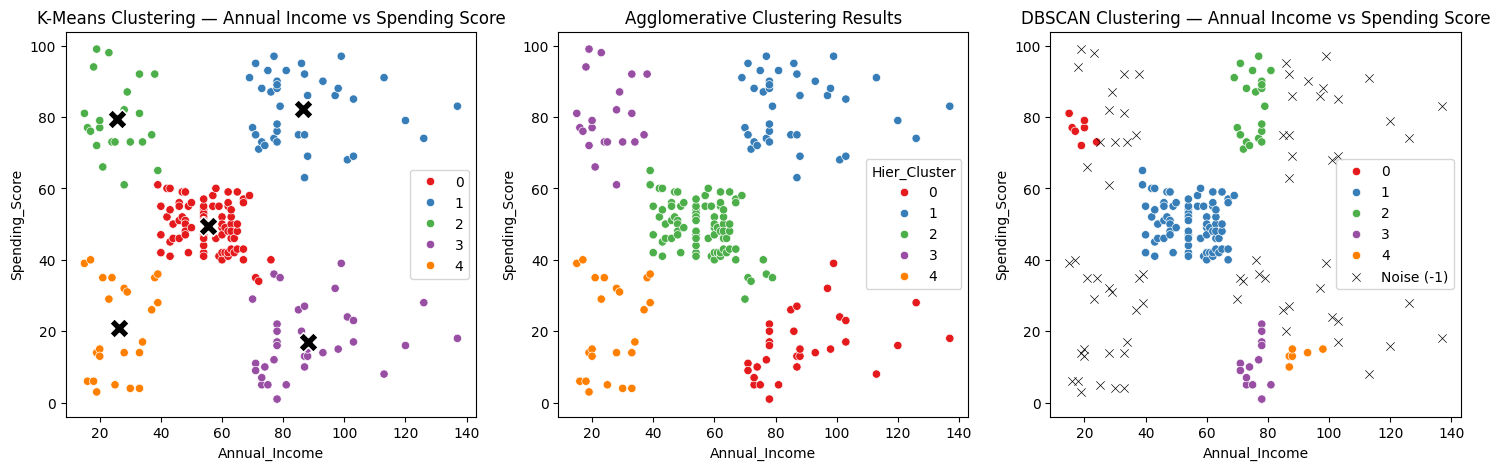

In [95]:
_,ax = plt.subplots(1,3,figsize=(18,5))

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster', data=df, palette='Set1',ax=ax[0])
sns.scatterplot(x=centroids[:,0], y=centroids[:,1], c='black', marker='X', s=200,ax=ax[0])
ax[0].set_title('K-Means Clustering — Annual Income vs Spending Score')

sns.scatterplot(x=df['Annual_Income'], y=df['Spending_Score'], hue=df['Hier_Cluster'], palette='Set1',ax=ax[1])
ax[1].set_title('Agglomerative Clustering Results')


sns.scatterplot(
    data=core_points, 
    x='Annual_Income', 
    y='Spending_Score', 
    hue='DBSCAN_Cluster', 
    palette='Set1',
    ax=ax[2])

sns.scatterplot(
    data=noise_points, 
    x='Annual_Income', 
    y='Spending_Score', 
    color='black', 
    marker='x', 
    ax=ax[2], 
    label='Noise (-1)'
)

ax[2].set_title('DBSCAN Clustering — Annual Income vs Spending Score')

plt.savefig('figure/all_compare.png',dpi=300)
plt.show()